# Barcelona GP 2025 - Results and Lap Data Analysis


In [42]:
import fastf1
import pandas
import matplotlib.pyplot as plt

In [43]:
#Session Import and Load
session = fastf1.get_session(
    2025,
    "Spanish Grand Prix",
    "Q"
)
session.load()

Request for URL https://raw.githubusercontent.com/theOehrly/f1schedule/master/schedule_2025.json failed; using cached response
Traceback (most recent call last):
  File "/mnt/Windows/Projects_S1/ProjectSlipstream/.venv/lib/python3.13/site-packages/urllib3/connectionpool.py", line 788, in urlopen
    response = self._make_request(
        conn,
    ...<10 lines>...
        **response_kw,
    )
  File "/mnt/Windows/Projects_S1/ProjectSlipstream/.venv/lib/python3.13/site-packages/urllib3/connectionpool.py", line 534, in _make_request
    response = conn.getresponse()
  File "/mnt/Windows/Projects_S1/ProjectSlipstream/.venv/lib/python3.13/site-packages/urllib3/connection.py", line 571, in getresponse
    httplib_response = super().getresponse()
  File "/usr/lib/python3.13/http/client.py", line 1450, in getresponse
    response.begin()
    ~~~~~~~~~~~~~~^^
  File "/usr/lib/python3.13/http/client.py", line 336, in begin
    version, status, reason = self._read_status()
                      

In [44]:
#Column Inspection
print(f"Reults Column: {session.results.columns}")
print(f"Laps Column: {session.laps.columns}")

Reults Column: Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')
Laps Column: Index(['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint',
       'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time',
       'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime',
       'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest',
       'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime',
       'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason',
       'FastF1Generated', 'IsAccurate'],
      dtype='object')


### Results column:
- Q1
- Q2
- Q3
- Time
- Status
- Points
- Laps

### Laps Column:
- Most of the columns are need!

In [45]:
#Results with Qualifying timings
results = session.results[[
    "Position",
    "Abbreviation",
    "TeamName",
    "Q1",
    "Q2",
    "Q3"
]]

results

,Position,Abbreviation,TeamName,Q1,Q2,Q3
81,1.0,PIA,McLaren,0 days 00:01:12.551000,0 days 00:01:11.998000,0 days 00:01:11.546000
4,2.0,NOR,McLaren,0 days 00:01:12.799000,0 days 00:01:12.056000,0 days 00:01:11.755000
1,3.0,VER,Red Bull Racing,0 days 00:01:12.798000,0 days 00:01:12.358000,0 days 00:01:11.848000
63,4.0,RUS,Mercedes,0 days 00:01:12.806000,0 days 00:01:12.407000,0 days 00:01:11.848000
44,5.0,HAM,Ferrari,0 days 00:01:13.058000,0 days 00:01:12.447000,0 days 00:01:12.045000
12,6.0,ANT,Mercedes,0 days 00:01:12.815000,0 days 00:01:12.585000,0 days 00:01:12.111000
16,7.0,LEC,Ferrari,0 days 00:01:13.014000,0 days 00:01:12.495000,0 days 00:01:12.131000
10,8.0,GAS,Alpine,0 days 00:01:13.081000,0 days 00:01:12.611000,0 days 00:01:12.199000
6,9.0,HAD,Racing Bulls,0 days 00:01:13.139000,0 days 00:01:12.461000,0 days 00:01:12.252000
14,10.0,ALO,Aston Martin,0 days 00:01:13.102000,0 days 00:01:12.523000,0 days 00:01:12.284000


In [46]:
#Examine Laps data
laps = session.laps

laps.head()

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 00:21:40.660000,PIA,81,NaT,1.0,1.0,0 days 00:19:36.751000,NaT,NaT,0 days 00:00:37.085000,...,True,McLaren,0 days 00:19:36.751000,2025-05-31 14:06:06.394,1,NaN,False,,False,False
1,0 days 00:22:53.211000,PIA,81,0 days 00:01:12.551000,2.0,1.0,NaT,NaT,0 days 00:00:21.477000,0 days 00:00:29.062000,...,True,McLaren,0 days 00:21:40.660000,2025-05-31 14:08:10.303,1,NaN,False,,False,True
2,0 days 00:24:36.804000,PIA,81,0 days 00:01:43.593000,3.0,1.0,NaT,0 days 00:24:34.189000,0 days 00:00:34.596000,0 days 00:00:37.166000,...,True,McLaren,0 days 00:22:53.211000,2025-05-31 14:09:22.854,1,NaN,False,,False,False
3,0 days 00:28:53.745000,PIA,81,NaT,4.0,2.0,0 days 00:26:59.708000,NaT,NaT,0 days 00:00:38.614000,...,False,McLaren,0 days 00:24:36.804000,2025-05-31 14:11:06.447,1,NaN,False,,False,False
4,0 days 00:30:49.757000,PIA,81,0 days 00:01:56.012000,5.0,2.0,NaT,0 days 00:30:15.930000,0 days 00:00:21.784000,0 days 00:00:31.625000,...,False,McLaren,0 days 00:28:53.745000,2025-05-31 14:15:23.388,1,NaN,False,,False,False


In [47]:
# Lap count
print(f"Total Lap Data Avilable = {len(laps)}")
print(f"Accurate Lap Data = {len(laps[laps["IsAccurate"] == True])}")

Total Lap Data Avilable = 247
Accurate Lap Data = 78


In [48]:
#Drivers available in the session
laps["Driver"].unique()

array(['PIA', 'NOR', 'VER', 'RUS', 'HAM', 'ANT', 'LEC', 'GAS', 'HAD',
       'ALO', 'ALB', 'BOR', 'LAW', 'STR', 'BEA', 'HUL', 'OCO', 'SAI',
       'COL', 'TSU'], dtype=object)

In [49]:
#Driver Specific Data
#1. Max Verstappen
max = laps.pick_drivers("VER")
max

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
29,0 days 00:23:21.610000,VER,1,NaT,1.0,1.0,0 days 00:21:16.971000,NaT,NaT,0 days 00:00:41.544000,...,True,Red Bull Racing,0 days 00:21:16.971000,2025-05-31 14:07:46.614,1,NaN,False,,False,False
30,0 days 00:24:34.408000,VER,1,0 days 00:01:12.798000,2.0,1.0,NaT,NaT,0 days 00:00:21.612000,0 days 00:00:29.189000,...,True,Red Bull Racing,0 days 00:23:21.610000,2025-05-31 14:09:51.253,1,NaN,False,,False,True
31,0 days 00:26:19.808000,VER,1,0 days 00:01:45.400000,3.0,1.0,NaT,0 days 00:26:17.009000,0 days 00:00:30.480000,0 days 00:00:42.479000,...,True,Red Bull Racing,0 days 00:24:34.408000,2025-05-31 14:11:04.051,1,NaN,False,,False,False
32,0 days 00:42:33.380000,VER,1,NaT,4.0,2.0,0 days 00:40:53.063000,NaT,NaT,0 days 00:00:42.293000,...,True,Red Bull Racing,0 days 00:26:19.808000,2025-05-31 14:12:49.451,1,NaN,False,,False,False
33,0 days 00:43:45.738000,VER,1,0 days 00:01:12.358000,5.0,2.0,NaT,NaT,0 days 00:00:21.617000,0 days 00:00:28.898000,...,True,Red Bull Racing,0 days 00:42:33.380000,2025-05-31 14:29:03.023,1,NaN,False,,False,True
34,0 days 00:45:53.219000,VER,1,0 days 00:02:07.481000,6.0,2.0,NaT,0 days 00:45:24.839000,0 days 00:00:30.517000,0 days 00:00:40,...,True,Red Bull Racing,0 days 00:43:45.738000,2025-05-31 14:30:15.381,1,NaN,False,,False,False
35,0 days 01:04:25.493000,VER,1,NaT,7.0,3.0,0 days 01:02:35.503000,NaT,NaT,0 days 00:00:37.875000,...,True,Red Bull Racing,0 days 00:45:53.219000,2025-05-31 14:32:22.862,1,NaN,False,,False,False
36,0 days 01:05:37.814000,VER,1,0 days 00:01:12.321000,8.0,3.0,NaT,NaT,0 days 00:00:21.454000,0 days 00:00:29.047000,...,True,Red Bull Racing,0 days 01:04:25.493000,2025-05-31 14:50:55.136,1,NaN,False,,False,True
37,0 days 01:07:20.101000,VER,1,0 days 00:01:42.287000,9.0,3.0,NaT,0 days 01:07:17.495000,0 days 00:00:28.333000,0 days 00:00:39.712000,...,True,Red Bull Racing,0 days 01:05:37.814000,2025-05-31 14:52:07.457,1,NaN,False,,False,False
38,0 days 01:13:03.089000,VER,1,NaT,10.0,4.0,0 days 01:11:01.276000,NaT,NaT,0 days 00:00:41.548000,...,True,Red Bull Racing,0 days 01:07:20.101000,2025-05-31 14:53:49.744,1,NaN,False,,False,False


In [50]:
#2. Charles Leclerc
leclerc = laps.pick_drivers("LEC")
leclerc

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
86,0 days 00:22:28.847000,LEC,16,NaT,1.0,1.0,0 days 00:20:38.742000,NaT,NaT,0 days 00:00:39.030000,...,True,Ferrari,0 days 00:20:38.742000,2025-05-31 14:07:08.385,1,NaN,False,,False,False
87,0 days 00:23:41.861000,LEC,16,0 days 00:01:13.014000,2.0,1.0,NaT,NaT,0 days 00:00:21.673000,0 days 00:00:29.184000,...,True,Ferrari,0 days 00:22:28.847000,2025-05-31 14:08:58.490,1,NaN,False,,False,True
88,0 days 00:25:57.770000,LEC,16,0 days 00:02:15.909000,3.0,1.0,NaT,0 days 00:25:21.892000,0 days 00:00:28.617000,0 days 00:00:38.250000,...,True,Ferrari,0 days 00:23:41.861000,2025-05-31 14:10:11.504,1,NaN,False,,False,False
89,0 days 00:31:16.822000,LEC,16,NaT,4.0,2.0,0 days 00:28:48.581000,0 days 00:31:13.972000,NaT,0 days 00:00:38.273000,...,True,Ferrari,0 days 00:25:57.770000,2025-05-31 14:12:27.413,1,NaN,False,,False,False
90,0 days 00:44:12.525000,LEC,16,NaT,5.0,3.0,0 days 00:42:12.187000,NaT,NaT,0 days 00:00:41.192000,...,True,Ferrari,0 days 00:31:16.822000,2025-05-31 14:17:46.465,1,NaN,False,,False,False
91,0 days 00:45:25.020000,LEC,16,0 days 00:01:12.495000,6.0,3.0,NaT,NaT,0 days 00:00:21.501000,0 days 00:00:28.955000,...,True,Ferrari,0 days 00:44:12.525000,2025-05-31 14:30:42.168,1,NaN,False,,False,True
92,0 days 00:47:01.985000,LEC,16,0 days 00:01:36.965000,7.0,3.0,NaT,0 days 00:46:59.191000,0 days 00:00:28.235000,0 days 00:00:36.347000,...,True,Ferrari,0 days 00:45:25.020000,2025-05-31 14:31:54.663,1,NaN,False,,False,False
93,0 days 00:53:17.058000,LEC,16,NaT,8.0,4.0,0 days 00:51:23.531000,NaT,NaT,0 days 00:00:38.458000,...,False,Ferrari,0 days 00:47:01.985000,2025-05-31 14:33:31.628,1,NaN,False,,False,False
94,0 days 00:54:40.282000,LEC,16,0 days 00:01:23.224000,9.0,4.0,NaT,0 days 00:54:37.490000,0 days 00:00:21.654000,0 days 00:00:29.354000,...,False,Ferrari,0 days 00:53:17.058000,2025-05-31 14:39:46.701,1,NaN,False,,False,False
95,0 days 01:05:59.577000,LEC,16,NaT,10.0,5.0,0 days 01:04:18.585000,NaT,NaT,0 days 00:00:40.574000,...,True,Ferrari,0 days 00:54:40.282000,2025-05-31 14:41:09.925,1,NaN,False,,False,False


In [51]:
# Max and Leclerc Tyre Ages
print("Max and Leclerc Fresh Tyre Period:")
print(f"Max Verstappen = {len(max[max["FreshTyre"] == True])}")
print(f"Charles Leclerc = {len(leclerc[leclerc["FreshTyre"] == True])}")

Max and Leclerc Fresh Tyre Period:
Max Verstappen = 12
Charles Leclerc = 10


In [52]:
#Fastest Lap
fastest_lap = laps.pick_fastest()
fastest_lap

Time                      0 days 01:13:39.533000
Driver                                       PIA
DriverNumber                                  81
LapTime                   0 days 00:01:11.546000
LapNumber                                   13.0
Stint                                        5.0
PitOutTime                                   NaT
PitInTime                                    NaT
Sector1Time               0 days 00:00:21.259000
Sector2Time               0 days 00:00:28.580000
Sector3Time               0 days 00:00:21.707000
Sector1SessionTime        0 days 01:12:49.246000
Sector2SessionTime        0 days 01:13:17.826000
Sector3SessionTime        0 days 01:13:39.533000
SpeedI1                                    294.0
SpeedI2                                    311.0
SpeedFL                                    297.0
SpeedST                                    326.0
IsPersonalBest                              True
Compound                                    SOFT
TyreLife            

In [53]:
# Deep examine
fastest_lap[["Driver","LapTime"]]

Driver                        PIA
LapTime    0 days 00:01:11.546000
dtype: object

## Race Results and Lap Analysis

In [98]:
# Import data
import sys,importlib
sys.path.append("../..")
import Sliplib.slipload as sl
import Sliplib.plotting as slipplot
import Sliplib.selection as datasel

importlib.reload(slipplot)

<module 'Sliplib.plotting' from '/mnt/Windows/Projects_S1/ProjectSlipstream/2026_Barcelona_GP/notebooks/../../Sliplib/plotting.py'>

In [55]:
race = sl.load_gp(2025,"Spanish Grand Prix","Race")
race.load()

core           INFO 	Loading data for Spanish Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 19 drivers: ['81', '4', '16', '63', '27', '44', '6', '10', '14', '1', '30', '5', '22', '55', '43', '31', '87', '12', '23']


In [56]:
race_laps = race.laps

In [57]:
race_laps

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
0,0 days 01:00:37.344000,VER,1,0 days 00:01:23.696000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.318000,...,False,Red Bull Racing,0 days 00:59:13.393000,2025-06-01 13:03:17.591,1,2.0,False,,False,False
1,0 days 01:01:57.427000,VER,1,0 days 00:01:20.083000,2.0,1.0,NaT,NaT,0 days 00:00:24.125000,0 days 00:00:32.278000,...,False,Red Bull Racing,0 days 01:00:37.344000,2025-06-01 13:04:41.542,1,2.0,False,,False,True
2,0 days 01:03:17.964000,VER,1,0 days 00:01:20.537000,3.0,1.0,NaT,NaT,0 days 00:00:23.816000,0 days 00:00:32.561000,...,False,Red Bull Racing,0 days 01:01:57.427000,2025-06-01 13:06:01.625,1,2.0,False,,False,True
3,0 days 01:04:38.996000,VER,1,0 days 00:01:21.032000,4.0,1.0,NaT,NaT,0 days 00:00:24.299000,0 days 00:00:32.612000,...,False,Red Bull Racing,0 days 01:03:17.964000,2025-06-01 13:07:22.162,1,2.0,False,,False,True
4,0 days 01:05:59.960000,VER,1,0 days 00:01:20.964000,5.0,1.0,NaT,NaT,0 days 00:00:24.223000,0 days 00:00:32.561000,...,False,Red Bull Racing,0 days 01:04:38.996000,2025-06-01 13:08:43.194,1,2.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1198,0 days 02:27:19.124000,BEA,87,0 days 00:01:20.255000,62.0,4.0,NaT,NaT,0 days 00:00:23.593000,0 days 00:00:32.490000,...,False,Haas F1 Team,0 days 02:25:58.869000,2025-06-01 14:30:03.067,1,14.0,False,,False,True
1199,0 days 02:28:38.031000,BEA,87,0 days 00:01:18.907000,63.0,4.0,NaT,NaT,0 days 00:00:22.884000,0 days 00:00:32.034000,...,False,Haas F1 Team,0 days 02:27:19.124000,2025-06-01 14:31:23.322,1,13.0,False,,False,True
1200,0 days 02:29:58.331000,BEA,87,0 days 00:01:20.300000,64.0,4.0,NaT,NaT,0 days 00:00:23.498000,0 days 00:00:32.736000,...,False,Haas F1 Team,0 days 02:28:38.031000,2025-06-01 14:32:42.229,1,13.0,False,,False,True
1201,0 days 02:31:18.413000,BEA,87,0 days 00:01:20.082000,65.0,4.0,NaT,NaT,0 days 00:00:23.363000,0 days 00:00:32.711000,...,False,Haas F1 Team,0 days 02:29:58.331000,2025-06-01 14:34:02.529,1,13.0,False,,False,True


In [58]:
# Max Qualified in 3. But, Finished race at position 10
# We Analyse
max = race_laps.pick_drivers("VER")

In [59]:
print(f"Total Number of Laps = {race_laps["LapNumber"].nunique()}")

Total Number of Laps = 66


In [60]:
max[["LapNumber","Position"]].tail(10)

,LapNumber,Position
56,57.0,3.0
57,58.0,3.0
58,59.0,3.0
59,60.0,3.0
60,61.0,4.0
61,62.0,4.0
62,63.0,4.0
63,64.0,5.0
64,65.0,5.0
65,66.0,5.0


Let's measure Lap Downfall of Max Verstappen. Max Classified at 10. But, he finished at 5. So, let's see the event

In [61]:
max.tail(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
56,0 days 02:18:19.264000,VER,1,0 days 00:02:06.705000,57.0,5.0,NaT,NaT,0 days 00:00:38.353000,0 days 00:00:48.618000,...,True,Red Bull Racing,0 days 02:16:12.559000,2025-06-01 14:20:16.757,4,3.0,False,,False,False
57,0 days 02:20:27.939000,VER,1,0 days 00:02:08.675000,58.0,5.0,NaT,NaT,0 days 00:00:37.403000,0 days 00:00:49.887000,...,True,Red Bull Racing,0 days 02:18:19.264000,2025-06-01 14:22:23.462,4,3.0,False,,False,False
58,0 days 02:22:30.596000,VER,1,0 days 00:02:02.657000,59.0,5.0,NaT,NaT,0 days 00:00:37.540000,0 days 00:00:48.275000,...,True,Red Bull Racing,0 days 02:20:27.939000,2025-06-01 14:24:32.137,4,3.0,False,,False,False
59,0 days 02:24:33.097000,VER,1,0 days 00:02:02.501000,60.0,5.0,NaT,NaT,0 days 00:00:35.804000,0 days 00:00:45.499000,...,True,Red Bull Racing,0 days 02:22:30.596000,2025-06-01 14:26:34.794,41,3.0,False,,False,False
60,0 days 02:25:51.959000,VER,1,0 days 00:01:18.862000,61.0,5.0,NaT,NaT,0 days 00:00:23.624000,0 days 00:00:32.097000,...,True,Red Bull Racing,0 days 02:24:33.097000,2025-06-01 14:28:37.295,1,4.0,True,TRACK LIMITS AT TURN 2 LAP 61,False,True
61,0 days 02:27:08.978000,VER,1,0 days 00:01:17.019000,62.0,5.0,NaT,NaT,0 days 00:00:22.725000,0 days 00:00:30.995000,...,True,Red Bull Racing,0 days 02:25:51.959000,2025-06-01 14:29:56.157,1,4.0,False,,False,True
62,0 days 02:28:26.586000,VER,1,0 days 00:01:17.608000,63.0,5.0,NaT,NaT,0 days 00:00:22.882000,0 days 00:00:31.341000,...,True,Red Bull Racing,0 days 02:27:08.978000,2025-06-01 14:31:13.176,1,4.0,False,,False,True
63,0 days 02:29:46.646000,VER,1,0 days 00:01:20.060000,64.0,5.0,NaT,NaT,0 days 00:00:22.740000,0 days 00:00:32.759000,...,True,Red Bull Racing,0 days 02:28:26.586000,2025-06-01 14:32:30.784,1,5.0,False,,False,True
64,0 days 02:31:04.768000,VER,1,0 days 00:01:18.122000,65.0,5.0,NaT,NaT,0 days 00:00:22.835000,0 days 00:00:31.771000,...,True,Red Bull Racing,0 days 02:29:46.646000,2025-06-01 14:33:50.844,1,5.0,False,,False,True
65,0 days 02:32:22.849000,VER,1,0 days 00:01:18.081000,66.0,5.0,NaT,NaT,0 days 00:00:22.562000,0 days 00:00:31.942000,...,True,Red Bull Racing,0 days 02:31:04.768000,2025-06-01 14:35:08.966,1,5.0,False,,False,True


In [62]:
race.results.loc[
    race.results["Abbreviation"] == "VER"
]

,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Position,ClassifiedPosition,GridPosition,Q1,Q2,Q3,Time,Status,Points,Laps
1,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,4781D7,red_bull,Max,Verstappen,Max Verstappen,...,10.0,10,3.0,NaT,NaT,NaT,0 days 00:00:21.826000,Finished,1.0,66.0


<module 'matplotlib.pyplot' from '/mnt/Windows/Projects_S1/ProjectSlipstream/.venv/lib/python3.13/site-packages/matplotlib/pyplot.py'>

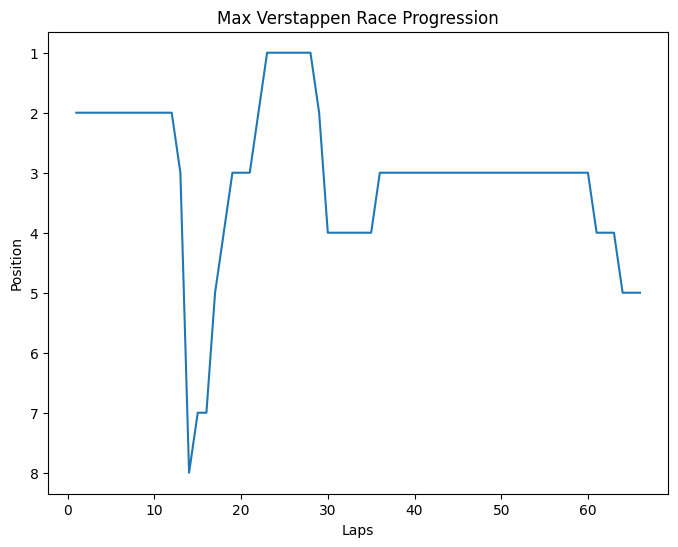

In [63]:
X = max["LapNumber"]
y = max["Position"]

plt.figure(figsize=(8,6))
plt.plot(X,y)
plt.gca().invert_yaxis()
plt.title("Max Verstappen Race Progression")
plt.xlabel("Laps")
plt.ylabel("Position")
plt

In [91]:
# Import Piastri
pia = race_laps.pick_drivers("PIA")
pia

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
1071,0 days 01:00:36.527000,PIA,81,0 days 00:01:22.879000,1.0,1.0,NaT,NaT,NaT,0 days 00:00:32.049000,...,True,McLaren,0 days 00:59:13.393000,2025-06-01 13:03:17.591,1,1.0,False,,False,False
1072,0 days 01:01:56.738000,PIA,81,0 days 00:01:20.211000,2.0,1.0,NaT,NaT,0 days 00:00:24.207000,0 days 00:00:32.317000,...,True,McLaren,0 days 01:00:36.527000,2025-06-01 13:04:40.725,1,1.0,False,,False,True
1073,0 days 01:03:16.604000,PIA,81,0 days 00:01:19.866000,3.0,1.0,NaT,NaT,0 days 00:00:23.812000,0 days 00:00:31.867000,...,True,McLaren,0 days 01:01:56.738000,2025-06-01 13:06:00.936,1,1.0,False,,False,True
1074,0 days 01:04:36.963000,PIA,81,0 days 00:01:20.359000,4.0,1.0,NaT,NaT,0 days 00:00:24.104000,0 days 00:00:32.173000,...,True,McLaren,0 days 01:03:16.604000,2025-06-01 13:07:20.802,1,1.0,False,,False,True
1075,0 days 01:05:57.430000,PIA,81,0 days 00:01:20.467000,5.0,1.0,NaT,NaT,0 days 00:00:24.036000,0 days 00:00:32.363000,...,True,McLaren,0 days 01:04:36.963000,2025-06-01 13:08:41.161,1,1.0,False,,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1132,0 days 02:27:03.627000,PIA,81,0 days 00:01:15.933000,62.0,4.0,NaT,NaT,0 days 00:00:22.740000,0 days 00:00:30.590000,...,False,McLaren,0 days 02:25:47.694000,2025-06-01 14:29:51.892,1,1.0,False,,False,True
1133,0 days 02:28:20.004000,PIA,81,0 days 00:01:16.377000,63.0,4.0,NaT,NaT,0 days 00:00:22.626000,0 days 00:00:30.748000,...,False,McLaren,0 days 02:27:03.627000,2025-06-01 14:31:07.825,1,1.0,False,,False,True
1134,0 days 02:29:36.584000,PIA,81,0 days 00:01:16.580000,64.0,4.0,NaT,NaT,0 days 00:00:22.698000,0 days 00:00:30.883000,...,False,McLaren,0 days 02:28:20.004000,2025-06-01 14:32:24.202,1,1.0,False,,False,True
1135,0 days 02:30:53.578000,PIA,81,0 days 00:01:16.994000,65.0,4.0,NaT,NaT,0 days 00:00:22.605000,0 days 00:00:31.169000,...,False,McLaren,0 days 02:29:36.584000,2025-06-01 14:33:40.782,1,1.0,False,,False,True


In [100]:
# Select Norris and Leclerc
nor,lec = datasel.pick_athletes(race_laps,["NOR","LEC"])

In [101]:
#Norris Data
nor.tail(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
665,0 days 02:18:16.250000,NOR,4,0 days 00:02:05.980000,57.0,4.0,NaT,NaT,0 days 00:00:38.928000,0 days 00:00:49.287000,...,False,McLaren,0 days 02:16:10.270000,2025-06-01 14:20:14.468,4,2.0,False,,False,False
666,0 days 02:20:26.507000,NOR,4,0 days 00:02:10.257000,58.0,4.0,NaT,NaT,0 days 00:00:38.503000,0 days 00:00:50.038000,...,False,McLaren,0 days 02:18:16.250000,2025-06-01 14:22:20.448,4,2.0,False,,False,False
667,0 days 02:22:29.789000,NOR,4,0 days 00:02:03.282000,59.0,4.0,NaT,NaT,0 days 00:00:37.447000,0 days 00:00:48.840000,...,False,McLaren,0 days 02:20:26.507000,2025-06-01 14:24:30.705,4,2.0,False,,False,False
668,0 days 02:24:32.490000,NOR,4,0 days 00:02:02.701000,60.0,4.0,NaT,NaT,0 days 00:00:35.781000,0 days 00:00:45.839000,...,False,McLaren,0 days 02:22:29.789000,2025-06-01 14:26:33.987,41,2.0,False,,False,False
669,0 days 02:25:48.677000,NOR,4,0 days 00:01:16.187000,61.0,4.0,NaT,NaT,0 days 00:00:22.929000,0 days 00:00:30.691000,...,False,McLaren,0 days 02:24:32.490000,2025-06-01 14:28:36.688,1,2.0,False,,False,True
670,0 days 02:27:04.891000,NOR,4,0 days 00:01:16.214000,62.0,4.0,NaT,NaT,0 days 00:00:22.632000,0 days 00:00:30.825000,...,False,McLaren,0 days 02:25:48.677000,2025-06-01 14:29:52.875,1,2.0,False,,False,True
671,0 days 02:28:21.607000,NOR,4,0 days 00:01:16.716000,63.0,4.0,NaT,NaT,0 days 00:00:22.652000,0 days 00:00:31.060000,...,False,McLaren,0 days 02:27:04.891000,2025-06-01 14:31:09.089,1,2.0,False,,False,True
672,0 days 02:29:38.470000,NOR,4,0 days 00:01:16.863000,64.0,4.0,NaT,NaT,0 days 00:00:22.500000,0 days 00:00:31.187000,...,False,McLaren,0 days 02:28:21.607000,2025-06-01 14:32:25.805,1,2.0,False,,False,True
673,0 days 02:30:55.975000,NOR,4,0 days 00:01:17.505000,65.0,4.0,NaT,NaT,0 days 00:00:22.660000,0 days 00:00:31.502000,...,False,McLaren,0 days 02:29:38.470000,2025-06-01 14:33:42.668,1,2.0,False,,False,True
674,0 days 02:32:13.494000,NOR,4,0 days 00:01:17.519000,66.0,4.0,NaT,NaT,0 days 00:00:22.775000,0 days 00:00:31.491000,...,False,McLaren,0 days 02:30:55.975000,2025-06-01 14:35:00.173,1,2.0,False,,False,True


In [103]:
#Leclerc Data
lec.tail(10)

,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,FreshTyre,Team,LapStartTime,LapStartDate,TrackStatus,Position,Deleted,DeletedReason,FastF1Generated,IsAccurate
308,0 days 02:18:25.623000,LEC,16,0 days 00:02:07.268000,57.0,4.0,NaT,NaT,0 days 00:00:37.623000,0 days 00:00:49.788000,...,False,Ferrari,0 days 02:16:18.355000,2025-06-01 14:20:22.553,4,4.0,False,,False,False
309,0 days 02:20:29.389000,LEC,16,0 days 00:02:03.766000,58.0,4.0,NaT,NaT,0 days 00:00:36.938000,0 days 00:00:49.075000,...,False,Ferrari,0 days 02:18:25.623000,2025-06-01 14:22:29.821,4,4.0,False,,False,False
310,0 days 02:22:32.326000,LEC,16,0 days 00:02:02.937000,59.0,4.0,NaT,NaT,0 days 00:00:37.634000,0 days 00:00:48.276000,...,False,Ferrari,0 days 02:20:29.389000,2025-06-01 14:24:33.587,4,4.0,False,,False,False
311,0 days 02:24:33.152000,LEC,16,0 days 00:02:00.826000,60.0,4.0,NaT,NaT,0 days 00:00:35.260000,0 days 00:00:45.613000,...,False,Ferrari,0 days 02:22:32.326000,2025-06-01 14:26:36.524,41,4.0,False,,False,False
312,0 days 02:25:50.699000,LEC,16,0 days 00:01:17.547000,61.0,4.0,NaT,NaT,0 days 00:00:23.280000,0 days 00:00:31.168000,...,False,Ferrari,0 days 02:24:33.152000,2025-06-01 14:28:37.350,1,3.0,False,,False,True
313,0 days 02:27:07.958000,LEC,16,0 days 00:01:17.259000,62.0,4.0,NaT,NaT,0 days 00:00:22.833000,0 days 00:00:31.092000,...,False,Ferrari,0 days 02:25:50.699000,2025-06-01 14:29:54.897,1,3.0,False,,False,True
314,0 days 02:28:25.567000,LEC,16,0 days 00:01:17.609000,63.0,4.0,NaT,NaT,0 days 00:00:22.894000,0 days 00:00:31.197000,...,False,Ferrari,0 days 02:27:07.958000,2025-06-01 14:31:12.156,1,3.0,False,,False,True
315,0 days 02:29:43.697000,LEC,16,0 days 00:01:18.130000,64.0,4.0,NaT,NaT,0 days 00:00:23.057000,0 days 00:00:31.475000,...,False,Ferrari,0 days 02:28:25.567000,2025-06-01 14:32:29.765,1,3.0,False,,False,True
316,0 days 02:31:02.341000,LEC,16,0 days 00:01:18.644000,65.0,4.0,NaT,NaT,0 days 00:00:23.050000,0 days 00:00:31.685000,...,False,Ferrari,0 days 02:29:43.697000,2025-06-01 14:33:47.895,1,3.0,False,,False,True
317,0 days 02:32:21.478000,LEC,16,0 days 00:01:19.137000,66.0,4.0,NaT,NaT,0 days 00:00:23.283000,0 days 00:00:31.853000,...,False,Ferrari,0 days 02:31:02.341000,2025-06-01 14:35:06.539,1,3.0,False,,False,True


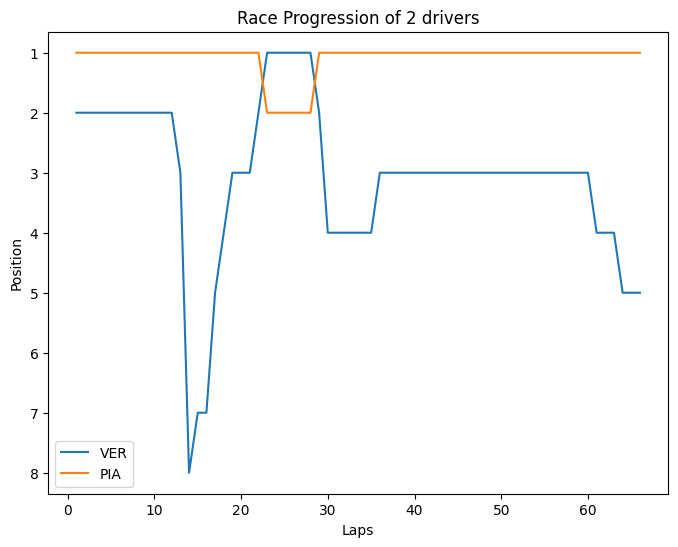

In [97]:
#Plot Max and Piastri Race Progression
slipplot.plot_race_progression([max,pia])